In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data_df = pd.read_csv("IBM_HR_Dataset.csv", index_col = 0)
data_df.head()

,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,,,,,,,,,,,,,,,,,,,,,
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2


Justify why Logistic Regression is suitable for this problem.

### Dataset Description

The IBM HR Analytics Employee Attrition dataset contains information about employees and different factors related to their work, such as age, department, job role, monthly income, job satisfaction, work-life balance, overtime, and years of experience.

The main purpose of this dataset is to analyze employee attrition and understand the factors that may be associated with employees leaving the company.

The target variable is **Attrition**, which has two categories:
- **Yes** – the employee left the company.
- **No** – the employee stayed with the company.

Since the target variable has two possible outcomes, this is a **binary classification problem**. Therefore, Logistic Regression can be used to predict the probability of employee attrition based on the available employee features.

# EDA

In [5]:
data_df.shape

(1470, 34)

The dataset contains **1,470 employee records and 34 columns**. Each row represents an employee, while the columns represent different employee-related features such as age, department, job role, income, satisfaction levels, and attrition.


In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 41 to 34
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Attrition                 1470 non-null   object
 1   BusinessTravel            1470 non-null   object
 2   DailyRate                 1470 non-null   int64 
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                   1470

The dataset contains both **numerical and categorical features**. Numerical columns are represented mainly by `int64`, while categorical columns such as Attrition, BusinessTravel, Department, Gender, JobRole, MaritalStatus, and OverTime are represented as `object`.
All columns contain **1,470 non-null values**, indicating that there are no missing values in the dataset.

In [7]:
data_df.isna().sum()

Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithC

The missing-value check shows **0 missing values in every column**. Therefore, no missing-value imputation or removal is required before further analysis.


In [9]:
data_df.duplicated().sum()

np.int64(0)

The dataset contains **no duplicate rows**. Therefore, no duplicate records need to be removed.


In [10]:
data_df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

<Axes: xlabel='Attrition', ylabel='count'>

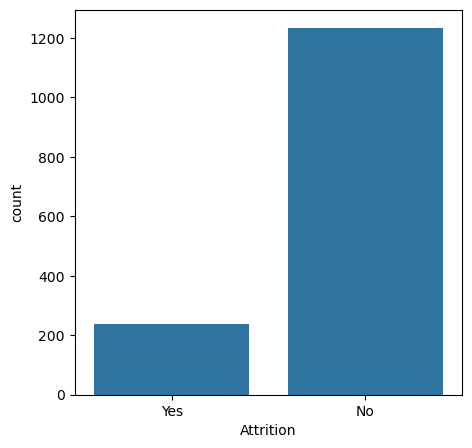

In [18]:
plt.figure(figsize=(5, 5))
sns.countplot(
    data = data_df,
    x = "Attrition", 
)

In [19]:
data_df.columns

Index(['Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

<Axes: xlabel='Department', ylabel='count'>

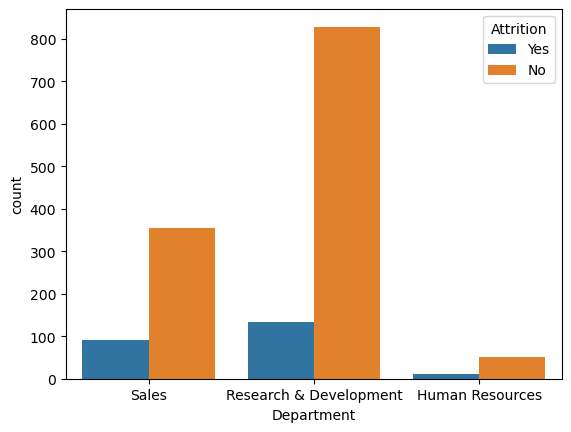

In [29]:
sns.countplot(
    data=data_df,
    x="Department",
    hue="Attrition"
)

<Axes: xlabel='OverTime', ylabel='count'>

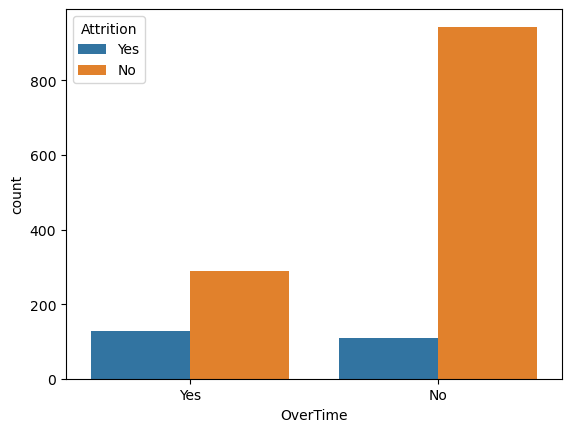

In [30]:
sns.countplot(
    data=data_df,
    x="OverTime",
    hue="Attrition"
)

In [32]:
pd.crosstab(
    data_df["OverTime"],
    data_df["Attrition"],
    normalize="index"
) * 100


Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [38]:
data_df.nunique().sort_values()

StandardHours                  1
Over18                         1
EmployeeCount                  1
Attrition                      2
PerformanceRating              2
OverTime                       2
Gender                         2
MaritalStatus                  3
BusinessTravel                 3
Department                     3
EnvironmentSatisfaction        4
StockOptionLevel               4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
HourlyRate                    71
DailyRate 

In [39]:
data_df["EmployeeCount"].unique()


array([1])

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

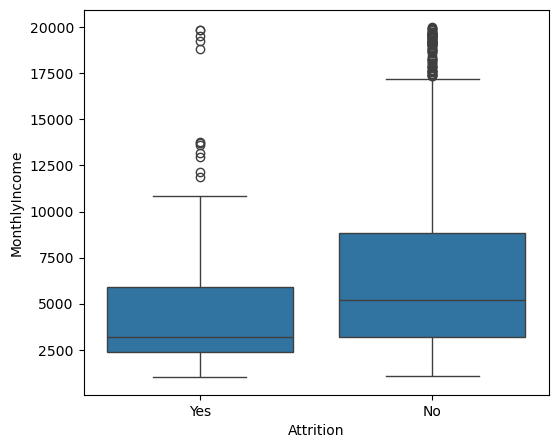

In [40]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=data_df, 
    x="Attrition", 
    y="MonthlyIncome")


In [44]:
# correlation
numerical_col =  data_df.select_dtypes(include="number")
numerical_col = numerical_data.loc[:, numerical_data.nunique() > 1]
correlation =  numerical_col.corr()

<Axes: >

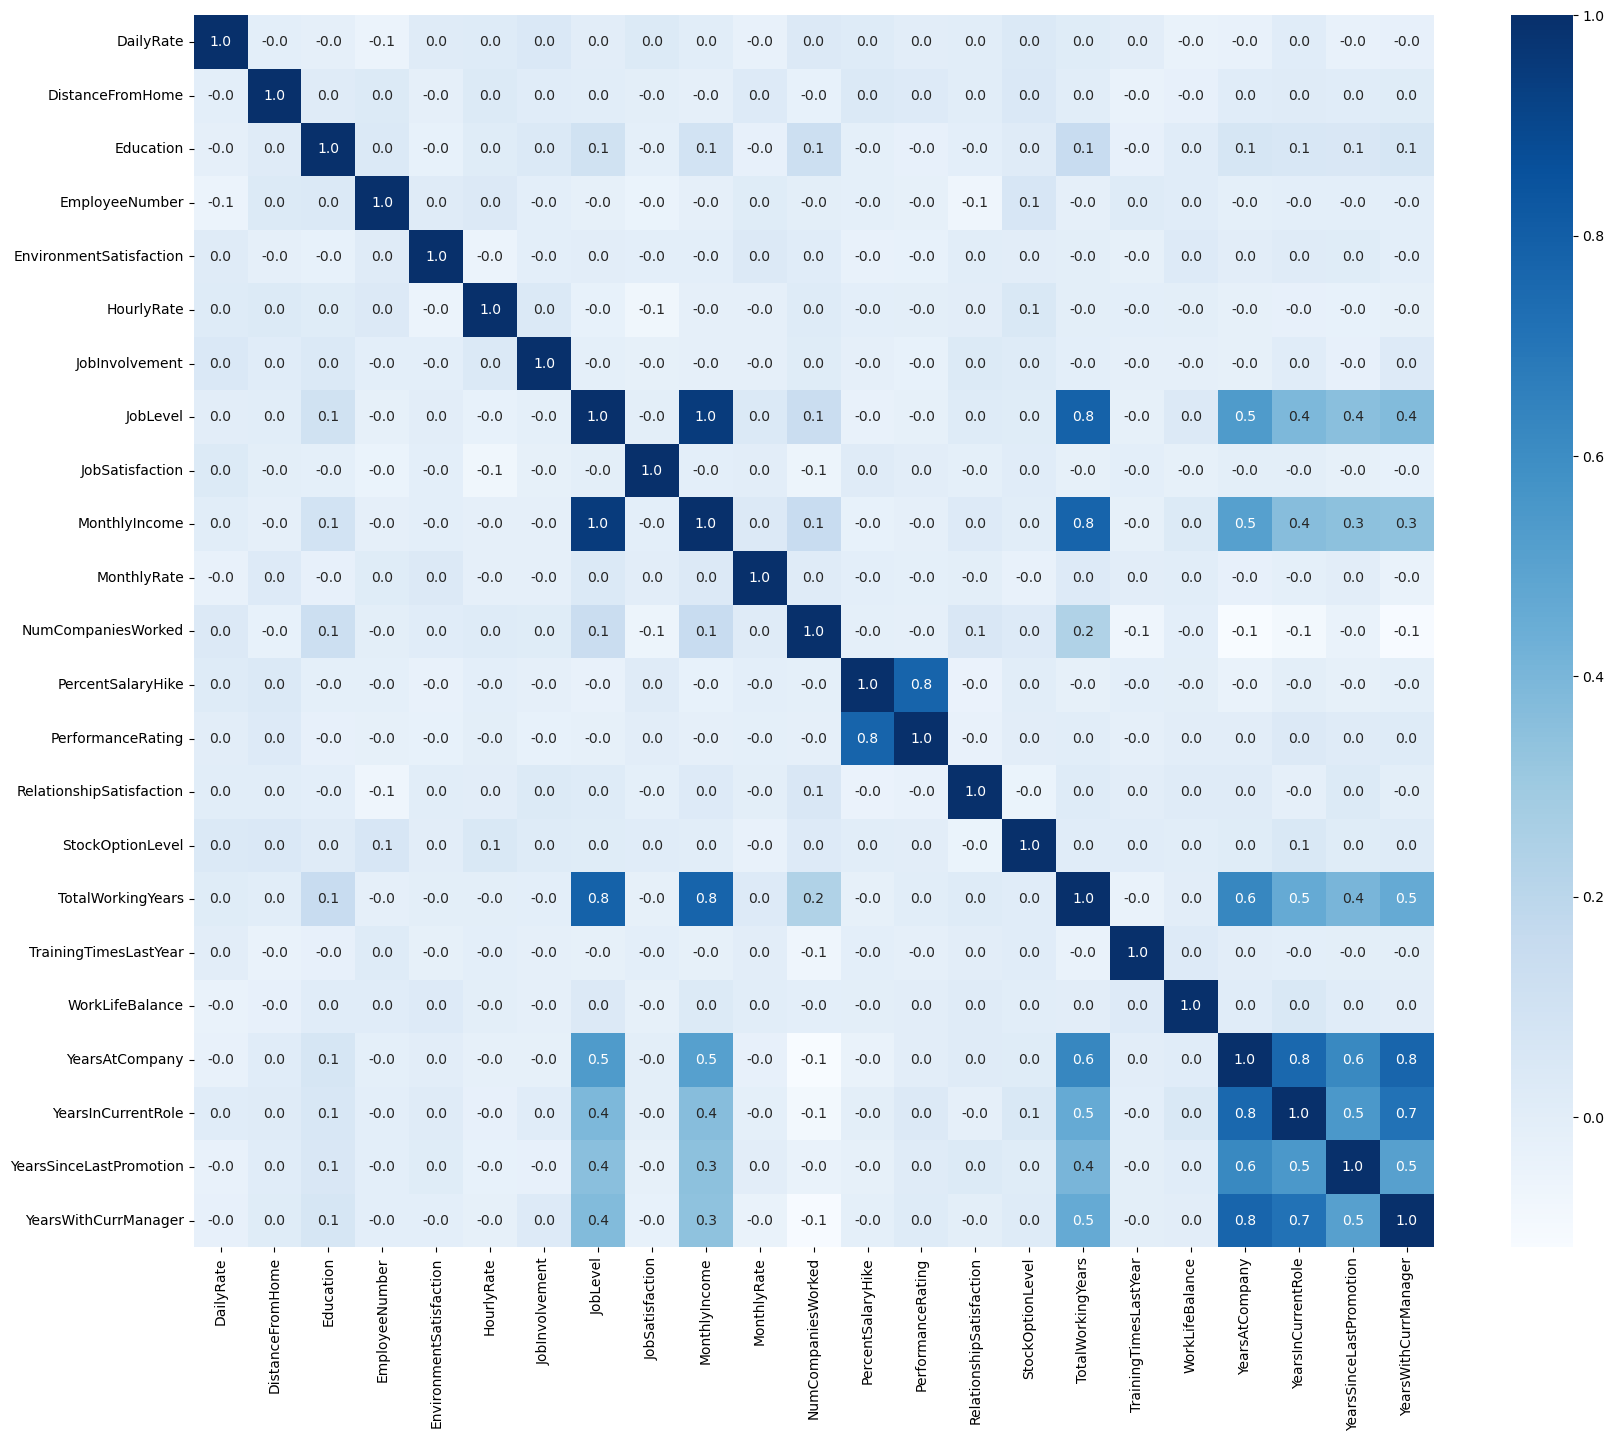

In [50]:
plt.figure(figsize=(20, 16))
sns.heatmap(
    data = correlation,
    annot= True,
    fmt= ".1f",
    cmap="Blues"
)

The correlation heatmap shows the relationships among the numerical features in the dataset. Strong positive correlations can be observed between some work-experience-related variables, such as YearsAtCompany, YearsInCurrentRole, and YearsWithCurrManager. JobLevel and MonthlyIncome also show a strong positive relationship. Many other numerical features have weak correlations.

In [51]:
categorical_cols = data_df.select_dtypes(include="object").columns
categorical_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [18]:
# encoding target
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [19]:
attrition_encoded = LabelEncoder()
data_df["Attrition"] =  attrition_encoded.fit_transform(data_df["Attrition"])

In [20]:
data_df.head()

,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
Age,,,,,,,,,,,,,,,,,,,,,
41,1,1102,1,2,1,1,2,94,3,2,...,False,False,False,True,False,False,False,True,False,True
49,0,279,8,1,1,2,3,61,2,2,...,False,False,True,False,False,False,True,False,True,False
37,1,1373,2,2,1,4,4,92,2,1,...,False,False,False,False,False,False,False,True,False,True
33,0,1392,3,4,1,5,4,56,3,1,...,False,False,True,False,False,False,True,False,False,True
27,0,591,2,1,1,7,1,40,3,1,...,False,False,False,False,False,False,True,False,True,False


In [21]:
# since over18 has only one value so we remove it
data_df.drop("Over18", axis=1, inplace=True)

In [7]:
data_df =  pd.get_dummies(
    data = data_df,
    columns = [ 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus','OverTime'],
    
)

In [22]:
data_df.head()

,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
Age,,,,,,,,,,,,,,,,,,,,,
41,1,1102,1,2,1,1,2,94,3,2,...,False,False,False,True,False,False,False,True,False,True
49,0,279,8,1,1,2,3,61,2,2,...,False,False,True,False,False,False,True,False,True,False
37,1,1373,2,2,1,4,4,92,2,1,...,False,False,False,False,False,False,False,True,False,True
33,0,1392,3,4,1,5,4,56,3,1,...,False,False,True,False,False,False,True,False,False,True
27,0,591,2,1,1,7,1,40,3,1,...,False,False,False,False,False,False,True,False,True,False


In [28]:
# train_test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [38]:
X =  data_df.drop("Attrition", axis = 1).to_numpy()
y = data_df["Attrition"].to_numpy()

In [39]:
scaler = StandardScaler()

In [40]:
X_scaled = scaler.fit_transform(X)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size= 0.2, random_state= 99
)

In [42]:
logistic_reg = LogisticRegression(max_iter=300)

In [44]:
logistic_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [45]:
y_predict = logistic_reg.predict(X_test)

In [46]:
y_predict

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [47]:
logistic_reg.score(X_test,y_test) #kati percent true bhayo bhanne dincha, term = accuracy paradox

0.8639455782312925

# Evaluation

In [72]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score,classification_report, roc_auc_score,roc_curve

In [54]:
confusion_matrix_IBM = confusion_matrix(y_test, y_predict)
confusion_matrix_IBM

array([[231,  11],
       [ 29,  23]])

<Axes: >

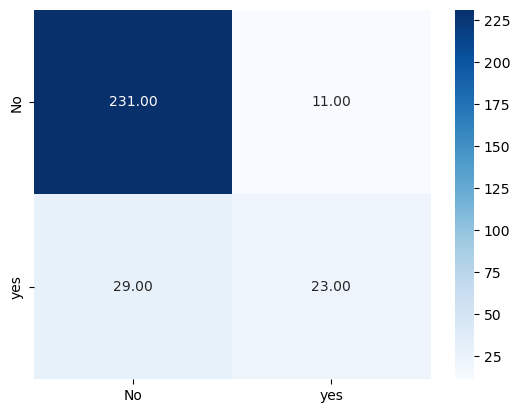

In [62]:
sns.heatmap(
    data = confusion_matrix_IBM,
    annot= True,
    fmt='.2f',
    xticklabels=["No","yes"],
    yticklabels=["No","yes"],
    cmap="Blues"
)

In [56]:
data_df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [63]:
accuracy_score(y_test, y_predict)

0.8639455782312925

In [64]:
precision_score(y_test, y_predict)

0.6764705882352942

In [65]:
recall_score(y_test, y_predict)

0.4423076923076923

In [66]:
f1_score(y_test, y_predict)

0.5348837209302325

In [73]:
#calculate FPR and TPR
fpr, tpr, thresholds = roc_curve(y_test, y_probability)
y_probability = logistic_reg.predict_proba(X_test)[:, 1]

In [76]:
roc_auc = roc_auc_score(y_test, y_probability)

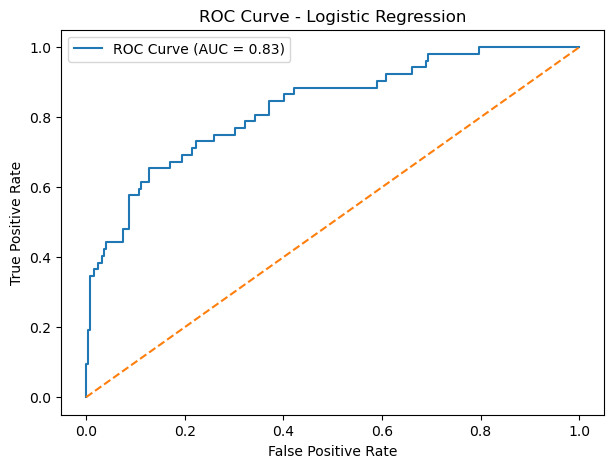

In [77]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

# Odd Ratio

# Hyperparameter Tuning & Model Optimization


Explain the difference between parameters and hyperparameters.

### Parameters vs Hyperparameters

**Parameters** are values that the model **learns automatically from the training data** during the training process.  
Examples: coefficients and intercept in Logistic Regression.

**Hyperparameters** are values that are **set before training** to control how the model learns and behaves. They can be adjusted or tuned to improve model performance.  
Examples: `C`, `max_iter`, and `solver` in Logistic Regression.

| Parameters | Hyperparameters |
|---|---|
| Learned automatically from data | Set or tuned by the user |
| Obtained during model training | Defined before model training |
| Example: coefficients, intercept | Example: C, max_iter, solver |

**In simple terms:**  
Parameter = learned by the model.  
Hyperparameter = chosen or tuned by us.

In [80]:
# Logistic Regression with class weight
balanced_model = LogisticRegression(max_iter=300,class_weight="balanced")

In [81]:
balanced_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [82]:
y_predict_balanced = balanced_model.predict(X_test)

In [84]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_predict_balanced))

# Metrics
print("Accuracy:", accuracy_score(y_test, y_predict_balanced))
print("Precision:", precision_score(y_test, y_predict_balanced))
print("Recall:", recall_score(y_test, y_predict_balanced))
print("F1 Score:", f1_score(y_test, y_predict_balanced))

# Probability for AUC
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

print("AUC Score:", roc_auc_score(y_test, y_prob_balanced))

Confusion Matrix:
[[182  60]
 [ 14  38]]
Accuracy: 0.7482993197278912
Precision: 0.3877551020408163
Recall: 0.7307692307692307
F1 Score: 0.5066666666666667
AUC Score: 0.8178639542275905


# Hyper Parameter Testing

In [89]:
from sklearn.model_selection import ParameterGrid, GridSearchCV, RandomizedSearchCV 

In [112]:
base_model = LogisticRegression(
    max_iter=300,
    class_weight="balanced"
)

In [113]:
hyperparams = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": ["balanced"]
}

In [114]:
random_search = RandomizedSearchCV(
    estimator = base_model,
    param_distributions = hyperparams,
    n_iter = 10,
    scoring = "f1",
    n_jobs = 8,
    random_state =  909
    
    
)

In [115]:
random_search.fit(X_train, y_train)

,estimator,LogisticRegre... max_iter=300)
,param_distributions,"{'C': [0.01, 0.1, ...], 'class_weight': ['balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,n_iter,10
,scoring,'f1'
,n_jobs,8
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,909
,error_score,nan


In [116]:
random_search.best_estimator_

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,300
,multi_class,'deprecated'


In [117]:
random_search.best_score_

np.float64(0.5030382601493558)

In [118]:
random_search.best_params_

{'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 10}

In [119]:
param_grid = [
    {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"]
    },
    {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"]
    }
]

In [120]:
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [121]:
grid_search.fit(X_train, y_train)

,estimator,LogisticRegre... max_iter=300)
,param_grid,"[{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, {'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [122]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 Score: 0.5037878853367621
